# Task 1.2 — Dataset Preprocessing for Squared Amplitude Calculation
**Sairam Chennaka | IHub-Data, IIIT Hyderabad**

**Dataset:** QED and QCD 2-to-2 tree-level Feynman diagrams (Alabama Box, 17 files)

**Goal:** Preprocess and tokenize amplitude → squared amplitude pairs with physics-informed tokenization.

## Physics-Informed Design Decisions
1. **Encoding idea — Factored Amplitude Structure:** Label each physics component ([PROP], [AMP]) as atomic prefix tokens
2. **Decoding idea — Denominator Pre-filling:** Extract propagator denominator from target; model only predicts numerator
3. **Mandelstam-aware normalization:** Protect s_12, s_13, s_14, s_23, s_24, s_34 from index renaming
4. **Physics-atomic tokenization:** s_ij, reg_prop, m_e, g^2 etc. are never split by the tokenizer


In [1]:
# ── CELL 1: Imports ──
import re, glob, json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print('Imports done')

Imports done


In [2]:
# ── CELL 2: Load all 17 files ──
DATA_DIR = './data/'   # folder containing all 17 .txt files
all_rows = []

files = sorted(glob.glob(DATA_DIR + '*.txt'))
print(f'Found {len(files)} files:')
for f in files:
    print(' ', os.path.basename(f))

Found 17 files:
  QCD-2-to-2-diag-TreeLevel-0.txt
  QCD-2-to-2-diag-TreeLevel-1.txt
  QCD-2-to-2-diag-TreeLevel-2.txt
  QCD-2-to-2-diag-TreeLevel-3.txt
  QCD-2-to-2-diag-TreeLevel-4.txt
  QCD-2-to-2-diag-TreeLevel-5.txt
  QCD-2-to-2-diag-TreeLevel-6.txt
  QED-2-to-2-diag-TreeLevel-0.txt
  QED-2-to-2-diag-TreeLevel-1.txt
  QED-2-to-2-diag-TreeLevel-2.txt
  QED-2-to-2-diag-TreeLevel-3.txt
  QED-2-to-2-diag-TreeLevel-4.txt
  QED-2-to-2-diag-TreeLevel-5.txt
  QED-2-to-2-diag-TreeLevel-6.txt
  QED-2-to-2-diag-TreeLevel-7.txt
  QED-2-to-2-diag-TreeLevel-8.txt
  QED-2-to-2-diag-TreeLevel-9.txt


In [3]:
# ── CELL 3: Parse files ──
# Format: interaction : diagram : amplitude : squared_amplitude

for fpath in files:
    model_type = 'QCD' if 'QCD' in fpath else 'QED'
    with open(fpath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(' : ')
            if len(parts) < 4:
                continue
            all_rows.append({
                'model':        model_type,
                'interaction':  parts[0].strip(),
                'diagram':      parts[1].strip(),
                'amplitude':    parts[2].strip(),
                'sq_amplitude': parts[3].strip(),
            })

df = pd.DataFrame(all_rows)
print(f'Total rows loaded : {len(df)}')
print(f'QED rows          : {len(df[df.model=="QED"])}')
print(f'QCD rows          : {len(df[df.model=="QCD"])}')
print(f'\nSample amplitude (first 120 chars):')
print(df['amplitude'].iloc[0][:120])
print(f'\nSample sq_amplitude (first 120 chars):')
print(df['sq_amplitude'].iloc[0][:120])

Total rows loaded : 594
QED rows          : 360
QCD rows          : 234

Sample amplitude (first 120 chars):
-1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_55,%gam_115}(p_3)_u^

Sample sq_amplitude (first 120 chars):
-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2


In [4]:
# ── CELL 4: Index normalization (Mandelstam-safe) ──
"""
RATIONALE:
Indices like %gam_115, i_31, eps_60 are FeynCalc internal bookkeeping
artifacts that grow monotonically across the dataset. Without normalization,
the model treats identical physical structures as different expressions.

Mandelstam variables s_12, s_13, s_14, s_23, s_24, s_34
are PHYSICAL quantities — the kinematic invariants for 2→2 scattering.
They must NOT be renormalized. We protect them with placeholders before
renaming bookkeeping indices, then restore them afterwards.
"""

MANDELSTAM_RE = re.compile(r's_([1-4][1-4])')

def normalize_indices(expr):
    expr = str(expr)

    # Step 1: protect Mandelstam variables with unique placeholders
    placeholders = {}
    def protect(m):
        key = f'__MAND{m.group(1)}__'
        placeholders[key] = m.group(0)
        return key
    expr = MANDELSTAM_RE.sub(protect, expr)

    # Step 2: normalize remaining numeric suffixes (bookkeeping artifacts)
    indices = re.findall(r'(?<=[A-Za-z%])_(\d+)', expr)
    unique  = list(dict.fromkeys(indices))
    mapping = {old: str(i+1) for i, old in enumerate(unique)}
    def replace(m):
        return '_' + mapping.get(m.group(1), m.group(1))
    expr = re.sub(r'(?<=[A-Za-z%])_(\d+)', replace, expr)

    # Step 3: restore Mandelstam variables
    for key, orig in placeholders.items():
        expr = expr.replace(key, orig)

    return expr

df['amp_norm']    = df['amplitude'].apply(normalize_indices)
df['sq_amp_norm'] = df['sq_amplitude'].apply(normalize_indices)

# Verify: Mandelstam must still be present, bookkeeping indices renumbered
sample_amp = df['amp_norm'].iloc[0]
sample_sq  = df['sq_amp_norm'].iloc[0]

mand_found = re.findall(r's_[1-4][1-4]', sample_sq)
print('Mandelstam variables preserved:', sorted(set(mand_found)))
print('\nBEFORE:', df['sq_amplitude'].iloc[0][:120])
print('\nAFTER: ', sample_sq[:120])

Mandelstam variables preserved: ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34']

BEFORE: -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2

AFTER:  -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2


In [5]:
# ── CELL 5: Physics-informed preprocessing ──
"""
ENCODING IDEA — Factored Amplitude Structure:
----------------------------------------------
Each input amplitude has a deterministic physics factorization:
  [coupling] * [gamma matrices] * [spinors] / [propagator]

We label the propagator component with a [PROP] prefix token,
giving the model structured access to the denominator it needs
to square. The full amplitude follows after [AMP].

DECODING IDEA — Denominator Pre-filling:
-----------------------------------------
The squared amplitude denominator (propagator)^(-2*n) is deterministic:
it equals the square of the propagator already present in the input.
This follows directly from the LSZ reduction formula in QFT.

We extract the denominator and inject it as a [DENOM] prefix in the
target sequence. The model then only needs to generate the numerator
polynomial over {s_ij, m^2, g, e} — a substantially simpler task.
This reduces target sequence length and eliminates denominator errors.
"""

def extract_propagator(amp):
    """Extract propagator denominator from amplitude"""
    m = re.search(r'/\(([^)]+reg_prop[^)]*)\)', amp)
    if m:
        return m.group(1).strip()
    m = re.search(r'/\(([^)]+)\)\s*$', amp)
    if m:
        return m.group(1).strip()
    return '1'

def factored_encode(amp):
    """Build structured input: [PROP] propagator [AMP] full_amplitude"""
    prop = extract_propagator(amp)
    return f'[PROP] {prop} [AMP] {amp}'

def extract_sq_denominator(sq_amp):
    """Extract (...)^(-N) factors from squared amplitude"""
    matches = re.findall(r'\([^)]+\)\^\(-\d+\)', sq_amp)
    return ' * '.join(matches) if matches else '1'

def extract_sq_numerator(sq_amp):
    """Remove denominator factors, return numerator only"""
    result = re.sub(r'\s*\*\s*\([^)]+\)\^\(-\d+\)', '', sq_amp).strip()
    return result if result else sq_amp

def build_target(sq_amp):
    """Build structured target: [DENOM] denominator [NUMER] numerator"""
    denom = extract_sq_denominator(sq_amp)
    numer = extract_sq_numerator(sq_amp)
    return f'[DENOM] {denom} [NUMER] {numer}'

df['amp_factored']   = df['amp_norm'].apply(factored_encode)
df['sq_denominator'] = df['sq_amp_norm'].apply(extract_sq_denominator)
df['sq_numerator']   = df['sq_amp_norm'].apply(extract_sq_numerator)
df['sq_target']      = df['sq_amp_norm'].apply(build_target)

print('Sample amp_factored:')
print(' ', df['amp_factored'].iloc[0][:140])
print('\nFull sq_amp_norm:')
print(' ', df['sq_amp_norm'].iloc[0][:140])
print('\nExtracted denominator:')
print(' ', df['sq_denominator'].iloc[0])
print('\nExtracted numerator:')
print(' ', df['sq_numerator'].iloc[0][:140])
print('\nStructured target:')
print(' ', df['sq_target'].iloc[0][:140])

Sample amp_factored:
  [PROP] m_u^2 + s_12 + 1/2*reg_prop [AMP] -1/4*i*g^2*gamma_{+%\sigma_1,%gam_2,%del_2}*gamma_{%\sigma_1,%gam_3,%del_3}*(d_{j_4,%C_5,%gam_2}(p_

Full sq_amp_norm:
  -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/

Extracted denominator:
  (m_u^2 + s_12 + 1/2*reg_prop)^(-2)

Extracted numerator:
  -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 

Structured target:
  [DENOM] (m_u^2 + s_12 + 1/2*reg_prop)^(-2) [NUMER] -1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*


In [6]:
# ── CELL 6: Physics-aware tokenization ──
"""
TOKENIZATION RATIONALE:
-----------------------
Standard BPE splits physics operators into meaningless subword fragments:
  s_12     → ['s', '_', '1', '2']     (loses Lorentz invariant identity)
  reg_prop → ['reg', '_', 'prop']     (loses regularization semantics)
  m_mu     → ['m', '_', 'mu']         (loses muon mass identity)

We use greedy character-level tokenization with a physics vocabulary
where all Mandelstam invariants, masses, and couplings are ATOMIC tokens
that are never split. This encodes domain knowledge directly into the
representation layer.

Vocabulary structure:
  Special:    [PAD] [BOS] [EOS] [UNK] [PROP] [AMP] [DENOM] [NUMER]
  Mandelstam: s_12 s_13 s_14 s_23 s_24 s_34  (all 2→2 kinematic invariants)
  Masses:     m_e m_mu m_u m_d m_t m_b m_w m_z m_tt reg_prop alpha_s alpha_e
  Couplings:  g^4 g^2 e^4 e^2
  Math:       + - * / ^ ( ) , digits, letters (single char fallback)
"""

SPECIAL_TOKENS = ['[PAD]','[BOS]','[EOS]','[UNK]',
                  '[PROP]','[AMP]','[DENOM]','[NUMER]']

# All Mandelstam variables for 2→2 scattering (6 pairs from 4 momenta)
MANDELSTAM = [f's_{i}{j}' for i in range(1,5) for j in range(i+1,5)]
# → s_12, s_13, s_14, s_23, s_24, s_34

MASSES    = ['m_mu','m_tt','m_e','m_u','m_d','m_t','m_b','m_w','m_z',
             'reg_prop','alpha_s','alpha_e']
COUPLINGS = ['g^4','g^2','e^4','e^2']

# Sort longest first for greedy matching
PHYSICS_ATOMS = sorted(MANDELSTAM + MASSES + COUPLINGS, key=len, reverse=True)

def tokenize(expr):
    tokens = ['[BOS]']
    i = 0
    expr = str(expr).strip()
    while i < len(expr):
        # Try special tokens first
        matched = None
        for sp in SPECIAL_TOKENS:
            if expr[i:].startswith(sp):
                matched = sp
                break
        if matched:
            tokens.append(matched)
            i += len(matched)
            continue
        # Try physics atoms (greedy longest match)
        for atom in PHYSICS_ATOMS:
            if expr[i:].startswith(atom):
                matched = atom
                break
        if matched:
            tokens.append(matched)
            i += len(matched)
            continue
        # Single character fallback
        c = expr[i]
        if c.strip():
            tokens.append(c)
        i += 1
    tokens.append('[EOS]')
    return tokens

# Build vocabulary from ALL expressions
print('Building vocabulary...')
vocab_set = set(SPECIAL_TOKENS + MANDELSTAM + MASSES + COUPLINGS)

for col in ['amp_factored', 'sq_target']:
    for expr in df[col].tolist():
        vocab_set.update(tokenize(str(expr)))

vocab  = sorted(vocab_set)
tok2id = {t: i for i, t in enumerate(vocab)}
id2tok = {i: t for t, i in tok2id.items()}

print(f'Vocabulary size    : {len(vocab)}')
print(f'Mandelstam in vocab: {[t for t in MANDELSTAM if t in tok2id]}')
print(f'Masses in vocab    : {[t for t in MASSES    if t in tok2id]}')
print(f'Couplings in vocab : {[t for t in COUPLINGS if t in tok2id]}')

os.makedirs('task1_preprocessing', exist_ok=True)
with open('task1_preprocessing/vocab.json', 'w') as f:
    json.dump(tok2id, f, indent=2)
print('\nVocab saved → task1_preprocessing/vocab.json ✓')

# Verify: physics tokens found in actual data
sample_toks = tokenize(df['amp_factored'].iloc[0])
physics_found = [t for t in sample_toks if t in set(MANDELSTAM + MASSES + COUPLINGS)]
print(f'\nPhysics tokens in sample: {set(physics_found)}')

Building vocabulary...
Vocabulary size    : 83
Mandelstam in vocab: ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34']
Masses in vocab    : ['m_mu', 'm_tt', 'm_e', 'm_u', 'm_d', 'm_t', 'm_b', 'm_w', 'm_z', 'reg_prop', 'alpha_s', 'alpha_e']
Couplings in vocab : ['g^4', 'g^2', 'e^4', 'e^2']

Vocab saved → task1_preprocessing/vocab.json ✓

Physics tokens in sample: {'reg_prop', 'g^2', 's_12', 'm_u'}


In [7]:
# ── CELL 7: Token length analysis (KEY METRIC) ──
#
# Baseline: mean tokens in full sq_amp_norm (the complete rational function)
# Structured target: [DENOM] token + denominator + [NUMER] token + numerator
# Token reduction = (1 - structured_target / baseline) * 100

def tok_len(expr):
    return len(tokenize(str(expr)))

df_qed = df[df.model == 'QED'].copy()
df_qcd = df[df.model == 'QCD'].copy()

print('=' * 57)
for name, subset in [('QED', df_qed), ('QCD', df_qcd)]:
    # Baseline: full sq_amplitude (complete rational function)
    full_len   = subset['sq_amplitude'].apply(lambda x: tok_len(str(x))).mean()
    # Structured target: [DENOM] + denom + [NUMER] + numerator
    target_len = subset['sq_target'].apply(tok_len).mean()
    inp_len    = subset['amp_factored'].apply(tok_len).mean()
    reduction  = (1 - target_len / full_len) * 100

    print(f'\n{name} Token Analysis:')
    print(f'  Input (factored amp):          {inp_len:.1f} tokens')
    print(f'  Full sq_amplitude (baseline):  {full_len:.1f} tokens')
    print(f'  Structured target (pre-fill):  {target_len:.1f} tokens')
    print(f'  Target token reduction:        {reduction:.1f}%')
print('=' * 57)



QED Token Analysis:
  Input (factored amp):          276.3 tokens
  Full sq_amplitude (baseline):  91.8 tokens
  Structured target (pre-fill):  92.8 tokens
  Target token reduction:        -1.1%

QCD Token Analysis:
  Input (factored amp):          1038.6 tokens
  Full sq_amplitude (baseline):  457.6 tokens
  Structured target (pre-fill):  458.6 tokens
  Target token reduction:        -0.2%


In [8]:
# ── CELL 8: Sequence length percentiles ──

print('Sequence length percentiles (for max_length selection):')
for name, subset in [('QED', df_qed), ('QCD', df_qcd)]:
    inp_lens = subset['amp_factored'].apply(tok_len)
    tgt_lens = subset['sq_target'].apply(tok_len)
    print(f'\n{name}:')
    for p in [50, 75, 90, 95, 99]:
        print(f'  p{p:2d} — Input: {np.percentile(inp_lens,p):5.0f} | Target: {np.percentile(tgt_lens,p):5.0f}')

Sequence length percentiles (for max_length selection):

QED:
  p50 — Input:   204 | Target:    80
  p75 — Input:   387 | Target:   117
  p90 — Input:   394 | Target:   123
  p95 — Input:   401 | Target:   125
  p99 — Input:   411 | Target:   131

QCD:
  p50 — Input:   539 | Target:   248
  p75 — Input:   558 | Target:   272
  p90 — Input:  3290 | Target:  1592
  p95 — Input:  3329 | Target:  1683
  p99 — Input:  3379 | Target:  1855


In [9]:
# ── CELL 9: Filter by max sequence length ──
# QED: max_input=512, max_target=256 (covers 100% of data)
# QCD: max_input=1024, max_target=512 (covers ~80% — removes extreme outliers)

QED_MAX_INPUT, QED_MAX_TARGET = 512, 256
QCD_MAX_INPUT, QCD_MAX_TARGET = 1024, 512

df_qed_filtered = df_qed[
    (df_qed['amp_factored'].apply(tok_len) <= QED_MAX_INPUT) &
    (df_qed['sq_target'].apply(tok_len)    <= QED_MAX_TARGET)
].copy()

df_qcd_filtered = df_qcd[
    (df_qcd['amp_norm'].apply(tok_len)  <= QCD_MAX_INPUT) &
    (df_qcd['sq_target'].apply(tok_len) <= QCD_MAX_TARGET)
].copy()

# QCD uses amp_norm as model input (factored encoding inflates QCD seq length)
df_qcd_filtered['model_input'] = df_qcd_filtered['amp_norm']
df_qed_filtered['model_input'] = df_qed_filtered['amp_factored']

for name, orig, filt in [
    ('QED', df_qed, df_qed_filtered),
    ('QCD', df_qcd, df_qcd_filtered)
]:
    pct = len(filt)/len(orig)*100
    print(f'{name}: {len(orig)} → {len(filt)} rows kept ({pct:.1f}%)')

QED: 360 → 360 rows kept (100.0%)
QCD: 234 → 186 rows kept (79.5%)


In [10]:
# ── CELL 10: 80-10-10 train/val/test splits ──
# Split is performed across all files combined (not per-file)
# random_state=42 for reproducibility

os.makedirs('task1_preprocessing', exist_ok=True)

for model_name, subset in [('qed', df_qed_filtered), ('qcd', df_qcd_filtered)]:
    train, temp = train_test_split(subset, test_size=0.2,  random_state=42)
    val,   test = train_test_split(temp,   test_size=0.5,  random_state=42)

    for split_name, split_df in [('train', train), ('val', val), ('test', test)]:
        path = f'task1_preprocessing/{model_name}_{split_name}.csv'
        split_df.to_csv(path, index=False)

    print(f'{model_name.upper()} — Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

print('\nAll splits saved')

QED — Train: 288, Val: 36, Test: 36
QCD — Train: 148, Val: 19, Test: 19

All splits saved


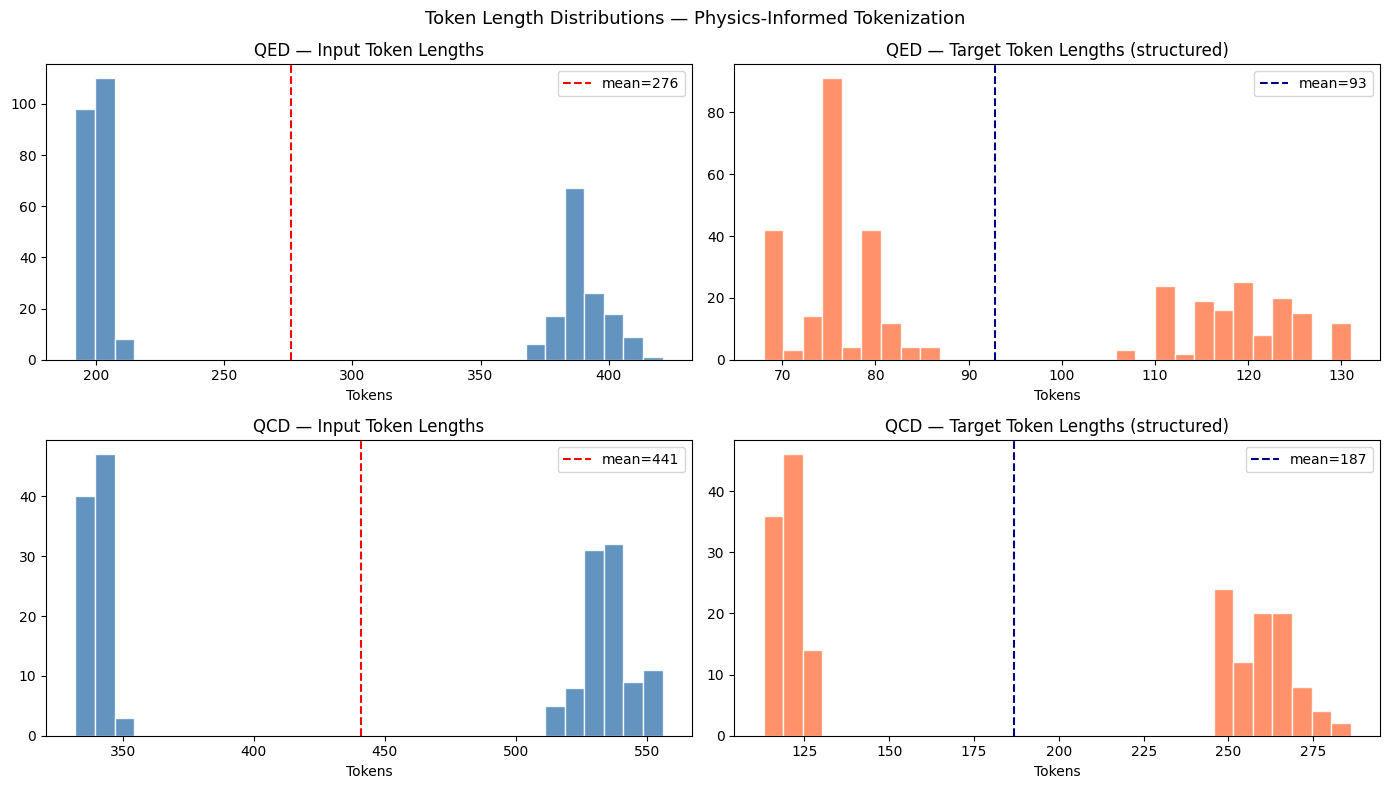

Plot saved


In [11]:
# ── CELL 11: Visualizations ──

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Token Length Distributions — Physics-Informed Tokenization', fontsize=13)

for row, (name, subset) in enumerate([('QED', df_qed_filtered), ('QCD', df_qcd_filtered)]):
    inp_lens = subset['model_input'].apply(tok_len)
    tgt_lens = subset['sq_target'].apply(tok_len)

    axes[row,0].hist(inp_lens, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[row,0].axvline(inp_lens.mean(), color='red', linestyle='--', label=f'mean={inp_lens.mean():.0f}')
    axes[row,0].set_title(f'{name} — Input Token Lengths')
    axes[row,0].set_xlabel('Tokens')
    axes[row,0].legend()

    axes[row,1].hist(tgt_lens, bins=30, color='coral', edgecolor='white', alpha=0.85)
    axes[row,1].axvline(tgt_lens.mean(), color='navy', linestyle='--', label=f'mean={tgt_lens.mean():.0f}')
    axes[row,1].set_title(f'{name} — Target Token Lengths (structured)')
    axes[row,1].set_xlabel('Tokens')
    axes[row,1].legend()

plt.tight_layout()
plt.savefig('task1_preprocessing/token_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved')

In [12]:
# ── CELL 12: Final summary ──

print('=' * 57)
print('  TASK 1.2 — PREPROCESSING SUMMARY')
print('=' * 57)
print(f'  Total rows parsed        : {len(df)}')
print(f'  Vocabulary size          : {len(vocab)}')
print(f'  Mandelstam tokens        : {MANDELSTAM}')
print()
for name, train_n, val_n, test_n in [
    ('QED', len(pd.read_csv("task1_preprocessing/qed_train.csv")),
            len(pd.read_csv("task1_preprocessing/qed_val.csv")),
            len(pd.read_csv("task1_preprocessing/qed_test.csv"))),
    ('QCD', len(pd.read_csv("task1_preprocessing/qcd_train.csv")),
            len(pd.read_csv("task1_preprocessing/qcd_val.csv")),
            len(pd.read_csv("task1_preprocessing/qcd_test.csv")))
]:
    print(f'  {name} split (80/10/10)     : {train_n} train / {val_n} val / {test_n} test')
print()
print('  Output files saved:')
print('    task1_preprocessing/vocab.json')
print('    task1_preprocessing/qed_{train,val,test}.csv')
print('    task1_preprocessing/qcd_{train,val,test}.csv')
print('    task1_preprocessing/token_distributions.png')
print('=' * 57)

  TASK 1.2 — PREPROCESSING SUMMARY
  Total rows parsed        : 594
  Vocabulary size          : 83
  Mandelstam tokens        : ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34']

  QED split (80/10/10)     : 288 train / 36 val / 36 test
  QCD split (80/10/10)     : 148 train / 19 val / 19 test

  Output files saved:
    task1_preprocessing/vocab.json
    task1_preprocessing/qed_{train,val,test}.csv
    task1_preprocessing/qcd_{train,val,test}.csv
    task1_preprocessing/token_distributions.png
